# Author: Dr Partha Majumdar
## ORC-ID: 0009-0002-7375-8034

In [1]:
import torch

# Step 1: Extract vocabulary from the sentence

In [2]:
# ---------------------------------------------------
# Sentence
# ---------------------------------------------------
sentence = "Children are playing games outside"

words = sentence.lower().split()
vocab = sorted(set(words))

word_to_index = {word: idx for idx, word in enumerate(vocab)}

# Print the word_to_index mapping
print("Word to Index Mapping:")
for word, idx in word_to_index.items():
    print(f"{word} -> {idx}")

Word to Index Mapping:
are -> 0
children -> 1
games -> 2
outside -> 3
playing -> 4


# Step 2: Select target and context words

In [3]:
target_word = "playing"
context_word = "games"

target_word_index = torch.tensor(word_to_index[target_word])
context_word_index = torch.tensor(word_to_index[context_word])

# Print word indices
print(f"Index of '{target_word}':", target_word_index.item())
print(f"Index of '{context_word}':", context_word_index.item())

Index of 'playing': 4
Index of 'games': 2


# Step 3: Extract subwords

In [4]:
# ---------------------------------------------------
# Function to extract subwords
# ---------------------------------------------------
def extract_subwords(word, min_n=3, max_n=3):
    word = f"<{word}>"
    subwords = []

    for n in range(min_n, max_n + 1):
        for i in range(len(word) - n + 1):
            subwords.append(word[i:i+n])

    return subwords

target_subwords = extract_subwords(target_word)
context_subwords = extract_subwords(context_word)

# Print results
print(f"Subwords of '{target_word}':")
print(target_subwords)

print(f"\nSubwords of '{context_word}':")
print(context_subwords)

Subwords of 'playing':
['<pl', 'pla', 'lay', 'ayi', 'yin', 'ing', 'ng>']

Subwords of 'games':
['<ga', 'gam', 'ame', 'mes', 'es>']


# Step 4: Build subword vocabulary

In [5]:
all_subwords = target_subwords + context_subwords
subword_vocab = sorted(set(all_subwords))

subword_to_index = {subword: idx for idx, subword in enumerate(subword_vocab)}

# Print the subword_to_index mapping
print("Subword to Index Mapping:")
for subword, idx in subword_to_index.items():
    print(f"{subword} -> {idx}")

Subword to Index Mapping:
<ga -> 0
<pl -> 1
ame -> 2
ayi -> 3
es> -> 4
gam -> 5
ing -> 6
lay -> 7
mes -> 8
ng> -> 9
pla -> 10
yin -> 11


# Step 5: Convert subwords into tensors

In [6]:
target_subword_indices = torch.tensor(
    [subword_to_index[subword] for subword in target_subwords]
)

# Print the tensor of subword indices
print("Target Subword Indices Tensor:")
print(target_subword_indices)

Target Subword Indices Tensor:
tensor([ 1, 10,  7,  3, 11,  6,  9])


# Step 6: Explicit Embedding Matrices

In [7]:
embedding_dim = 6

# Subword embedding matrix (|G| x d)
subword_embedding_matrix = torch.randn(len(subword_vocab), embedding_dim)

# Output word embedding matrix (|V| x d)
output_embedding_matrix = torch.randn(len(vocab), embedding_dim)

print("Subword Embedding Matrix Shape:", subword_embedding_matrix.shape)
print("Word Embedding Matrix Shape   :", output_embedding_matrix.shape)

print("\nSubword Embedding Matrix (|G| x d):")
for i, row in enumerate(subword_embedding_matrix.detach().numpy()):
    print(f"g{i}: {row}")

print("\nOutput Word Embedding Matrix (|V| x d):")
for i, row in enumerate(output_embedding_matrix.detach().numpy()):
    print(f"w{i}: {row}")

Subword Embedding Matrix Shape: torch.Size([12, 6])
Word Embedding Matrix Shape   : torch.Size([5, 6])

Subword Embedding Matrix (|G| x d):
g0: [ 0.22964735 -0.00345273 -0.73832494  1.468815   -1.3658093   1.1803695 ]
g1: [ 0.04123523  1.0086634   0.7930635   0.06795967 -0.0951111   1.0711416 ]
g2: [-1.7556881   0.34282184  0.9395444  -0.58253574  0.2587884  -0.8897495 ]
g3: [ 0.3118317   0.13254368  0.90998054 -0.667283    1.1861441   0.00484137]
g4: [ 1.6160336  -0.87338495  0.745569   -0.3741121  -0.80977404 -1.7205963 ]
g5: [-1.9610924   0.77511483  1.1339983   0.7138299  -1.2497432  -0.880981  ]
g6: [-0.1036744   0.00569476 -0.5102405  -0.23769076 -0.46307492  0.47567892]
g7: [ 1.340078   -0.01033799  0.47988737 -0.01562162  0.96220195  0.47751725]
g8: [-0.6834343   0.62871665 -0.2922333   1.4186424  -0.09966037  1.1711199 ]
g9: [ 0.6964929  -0.14955923 -0.831448   -2.5841644  -1.8853096  -1.3557968 ]
g10: [ 0.9958116  -0.7798854   0.86633044  0.86361367  0.68688387 -0.91902167]
g

# Step 7: Manual embedding lookup for subwords

In [8]:
target_subword_vectors = subword_embedding_matrix[target_subword_indices]
# Shape: [num_subwords, embedding_dim]
print("target_subword_vector:\n", target_subword_vectors.detach().numpy())

target_subword_vector:
 [[ 0.04123523  1.0086634   0.7930635   0.06795967 -0.0951111   1.0711416 ]
 [ 0.9958116  -0.7798854   0.86633044  0.86361367  0.68688387 -0.91902167]
 [ 1.340078   -0.01033799  0.47988737 -0.01562162  0.96220195  0.47751725]
 [ 0.3118317   0.13254368  0.90998054 -0.667283    1.1861441   0.00484137]
 [ 0.01099141 -0.26920182 -1.2909113  -2.4745982  -0.46283677 -0.6410387 ]
 [-0.1036744   0.00569476 -0.5102405  -0.23769076 -0.46307492  0.47567892]
 [ 0.6964929  -0.14955923 -0.831448   -2.5841644  -1.8853096  -1.3557968 ]]


# Step 8: Aggregate subwords → word vector

In [9]:
target_word_vector = target_subword_vectors.mean(dim=0)
print("target_word_vector:\n", target_word_vector.detach().numpy())

target_word_vector:
 [ 0.47039518 -0.00886894  0.05952315 -0.72111213 -0.0101575  -0.12666829]


# Step 9: Manual lookup for context word embedding

In [10]:
context_word_vector = output_embedding_matrix[context_word_index]
print("context_word_vector:\n", context_word_vector.detach().numpy())

context_word_vector:
 [-0.4316001   0.80935043 -1.6998298   1.3529379   0.939098   -1.7127466 ]


# Step 10: Compute dot product

In [11]:
score = torch.dot(target_word_vector, context_word_vector)
print("score:", score)

score: tensor(-1.0796)


# Step 11: Sigmoid

In [12]:
probability = torch.sigmoid(score)
print("probability:", probability)

probability: tensor(0.2536)


# Outputs

In [13]:
print("\nSentence            :", sentence)
print("Target word         :", target_word)
print("Context word        :", context_word)
print("Target vector shape :", target_word_vector.shape)
print("Context vector shape:", context_word_vector.shape)
print("Score               :", score.item())
print("Probability         :", probability.item())


Sentence            : Children are playing games outside
Target word         : playing
Context word        : games
Target vector shape : torch.Size([6])
Context vector shape: torch.Size([6])
Score               : -1.0795880556106567
Probability         : 0.25358399748802185


# Neural Network

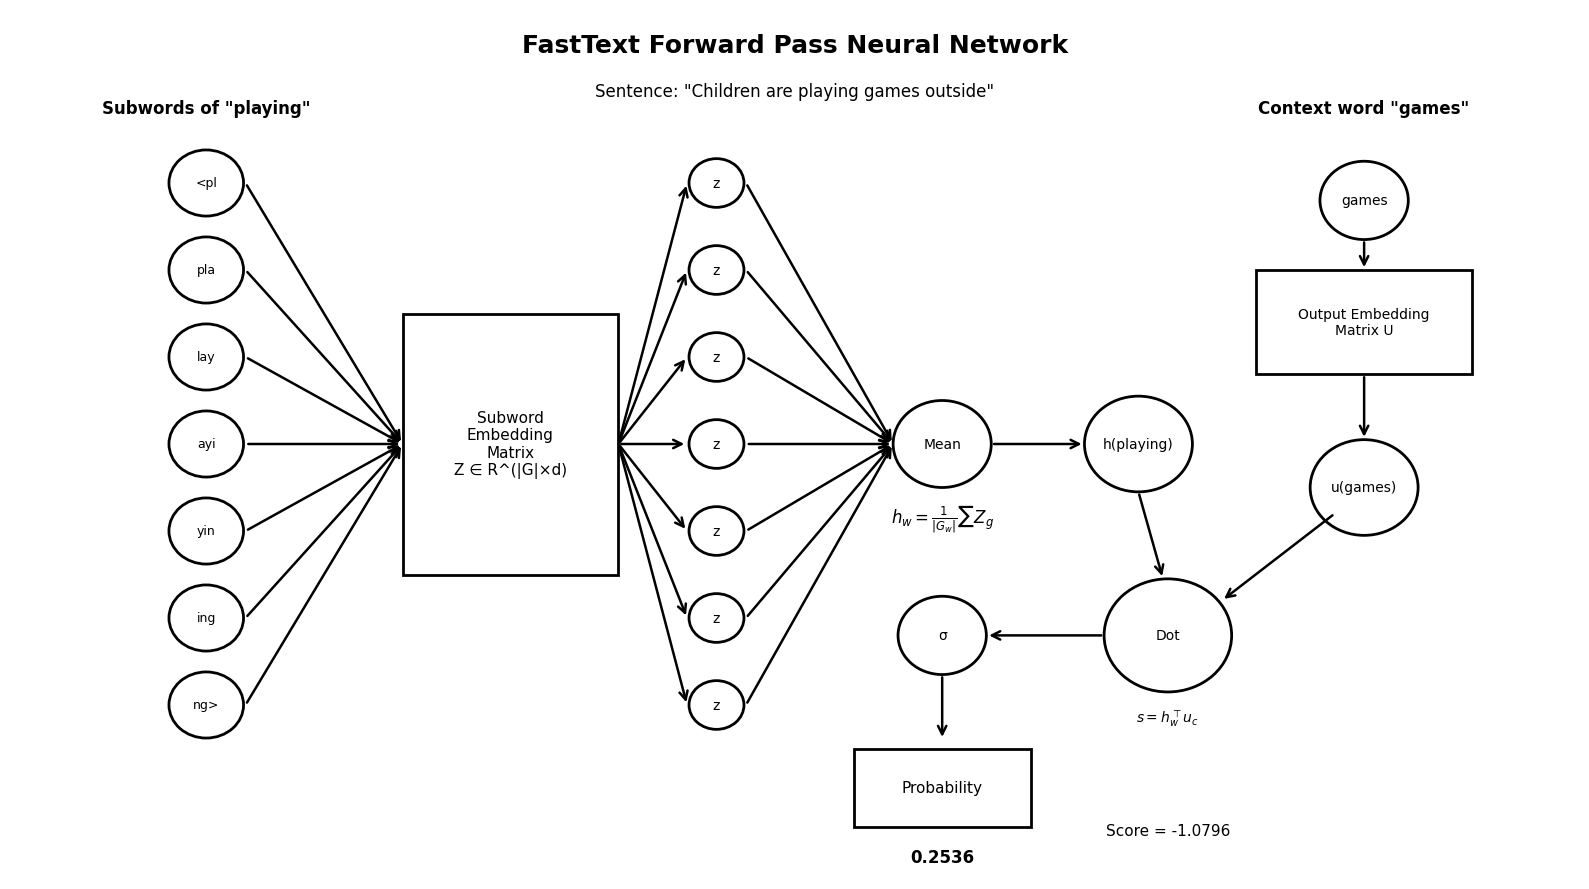

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

# ---------------------------------------------------
# Use existing variables from the notebook
# ---------------------------------------------------
score_value = float(score.item())
probability_value = float(probability.item())

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

# ---------------------------------------------------
# Helper functions
# ---------------------------------------------------
def draw_circle(x, y, text, radius=0.35, fontsize=10):
    circle = Circle((x, y), radius, fill=False, linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def draw_box(x, y, w, h, text, fontsize=10):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)

def draw_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle="->",
                            mutation_scale=15,
                            linewidth=1.8)
    ax.add_patch(arrow)

# ---------------------------------------------------
# Dynamic subword placement
# ---------------------------------------------------
top_y = 8.0
bottom_y = 2.0
step = (top_y - bottom_y) / (len(target_subwords) - 1)
subword_y = [top_y - i * step for i in range(len(target_subwords))]

# ---------------------------------------------------
# Title
# ---------------------------------------------------
ax.text(8, 9.5, "FastText Forward Pass Neural Network",
        ha="center", fontsize=18, fontweight="bold")

ax.text(8, 9.0, f'Sentence: "{sentence}"',
        ha="center", fontsize=12)

# ---------------------------------------------------
# Subwords
# ---------------------------------------------------
ax.text(2.0, 8.8, f'Subwords of "{target_word}"',
        ha="center", fontsize=12, fontweight="bold")

for sw, y in zip(target_subwords, subword_y):
    draw_circle(2.0, y, sw, radius=0.38, fontsize=9)
    draw_arrow(2.4, y, 4.0, 5.0)

# ---------------------------------------------------
# Embedding matrix
# ---------------------------------------------------
draw_box(4.0, 3.5, 2.2, 3.0, "Subword\nEmbedding\nMatrix\nZ ∈ R^(|G|×d)", fontsize=11)

# ---------------------------------------------------
# Subword vectors
# ---------------------------------------------------
for y in subword_y:
    draw_circle(7.2, y, "z", radius=0.28)
    draw_arrow(6.2, 5.0, 6.9, y)

# ---------------------------------------------------
# Mean node
# ---------------------------------------------------
draw_circle(9.5, 5.0, "Mean", radius=0.5)
for y in subword_y:
    draw_arrow(7.5, y, 9.0, 5.0)

ax.text(9.5, 4.1, r"$h_w = \frac{1}{|G_w|}\sum Z_g$", ha="center", fontsize=12)

# ---------------------------------------------------
# Word vector
# ---------------------------------------------------
draw_circle(11.5, 5.0, f"h({target_word})", radius=0.55)
draw_arrow(10.0, 5.0, 10.95, 5.0)

# ---------------------------------------------------
# Context path
# ---------------------------------------------------
ax.text(13.8, 8.8, f'Context word "{context_word}"',
        ha="center", fontsize=12, fontweight="bold")

draw_circle(13.8, 7.8, context_word, radius=0.45)
draw_box(12.7, 5.8, 2.2, 1.2, "Output Embedding\nMatrix U", fontsize=10)

draw_arrow(13.8, 7.35, 13.8, 7.0)

draw_circle(13.8, 4.5, f"u({context_word})", radius=0.55)
draw_arrow(13.8, 5.8, 13.8, 5.05)

# ---------------------------------------------------
# Dot product
# ---------------------------------------------------
draw_circle(11.8, 2.8, "Dot", radius=0.65)
draw_arrow(11.5, 4.45, 11.75, 3.45)
draw_arrow(13.5, 4.2, 12.35, 3.2)

ax.text(11.8, 1.8, r"$s = h_w^\top u_c$", ha="center")

# ---------------------------------------------------
# Sigmoid
# ---------------------------------------------------
draw_circle(9.5, 2.8, "σ", radius=0.45)
draw_arrow(11.15, 2.8, 9.95, 2.8)

# ---------------------------------------------------
# Probability (FIXED: directly BELOW arrow)
# ---------------------------------------------------
# Arrow downward
draw_arrow(9.5, 2.35, 9.5, 1.6)

# Box placed BELOW arrow (no overlap)
draw_box(8.6, 0.6, 1.8, 0.9, "Probability", fontsize=11)

# Value BELOW box
ax.text(9.5, 0.2, f"{probability_value:.4f}",
        ha="center", fontsize=12, fontweight="bold")

# ---------------------------------------------------
# Score annotation
# ---------------------------------------------------
ax.text(11.8, 0.5, f"Score = {score_value:.4f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()